In [1]:
import pandas as pd

In [16]:
"""
IMDB Movie Data — Descriptive Analytics
Covers: column renaming (snake_case), summary stats, groupby,
        pivot tables, crosstabs, and seaborn/matplotlib visualisations.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
PALETTE = "coolwarm"
FIG_DIR  = "."           # change to a folder path if you prefer a sub-directory

# ── 1. Load & rename columns to snake_case ────────────────────────────────────
df = pd.read_csv("/Users/armandovieira/Tartu/Data/IMDB-Movie-Data.csv")

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r"[\s\(\)]+", "_", regex=True)
      .str.replace(r"_+$", "", regex=True)          # trailing underscores
)

print("── Column names (snake_case) ──────────────────────────────")
print(df.columns.tolist(), "\n")

── Column names (snake_case) ──────────────────────────────
['rank', 'title', 'genre', 'description', 'director', 'actors', 'year', 'runtime_minutes', 'rating', 'votes', 'revenue_millions', 'metascore'] 



In [17]:
df

,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Secret in Their Eyes,"Crime,Drama,Mystery","A tight-knit team of rising investigators, alo...",Billy Ray,"Chiwetel Ejiofor, Nicole Kidman, Julia Roberts...",2015,111,6.2,27585,NaN,45.0
996,997,Hostel: Part II,Horror,Three American college students studying abroa...,Eli Roth,"Lauren German, Heather Matarazzo, Bijou Philli...",2007,94,5.5,73152,17.54,46.0
997,998,Step Up 2: The Streets,"Drama,Music,Romance",Romantic sparks occur between two dance studen...,Jon M. Chu,"Robert Hoffman, Briana Evigan, Cassie Ventura,...",2008,98,6.2,70699,58.01,50.0
998,999,Search Party,"Adventure,Comedy",A pair of friends embark on a mission to reuni...,Scot Armstrong,"Adam Pally, T.J. Miller, Thomas Middleditch,Sh...",2014,93,5.6,4881,NaN,22.0


In [18]:
df.isnull().sum()

rank                  0
title                 0
genre                 0
description           0
director              0
actors                0
year                  0
runtime_minutes       0
rating                0
votes                 0
revenue_millions    128
metascore            64
dtype: int64

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
rank,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
title,1000,999,The Host,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,1000,207,"Action,Adventure,Sci-Fi",50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,1000,1000,A stuffy businessman finds himself trapped ins...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,1000,644,Ridley Scott,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actors,1000,996,"Gerard Butler, Aaron Eckhart, Morgan Freeman,A...",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1000.0,NaN,NaN,NaN,2012.783,3.205962,2006.0,2010.0,2014.0,2016.0,2016.0
runtime_minutes,1000.0,NaN,NaN,NaN,113.172,18.810908,66.0,100.0,111.0,123.0,191.0
rating,1000.0,NaN,NaN,NaN,6.7232,0.945429,1.9,6.2,6.8,7.4,9.0
votes,1000.0,NaN,NaN,NaN,169808.255,188762.647518,61.0,36309.0,110799.0,239909.75,1791916.0


In [11]:
df[df.rating<2].head()

,rank,title,genre,description,director,actors,year,runtime_minutes,rating,votes,revenue_millions,metascore
829,830,Disaster Movie,Comedy,"Over the course of one evening, an unsuspectin...",Jason Friedberg,"Carmen Electra, Vanessa Lachey,Nicole Parker, ...",2008,87,1.9,77207,14.17,15.0


In [20]:
df.dtypes

rank                  int64
title                object
genre                object
description          object
director             object
actors               object
year                  int64
runtime_minutes       int64
rating              float64
votes                 int64
revenue_millions    float64
metascore           float64
dtype: object

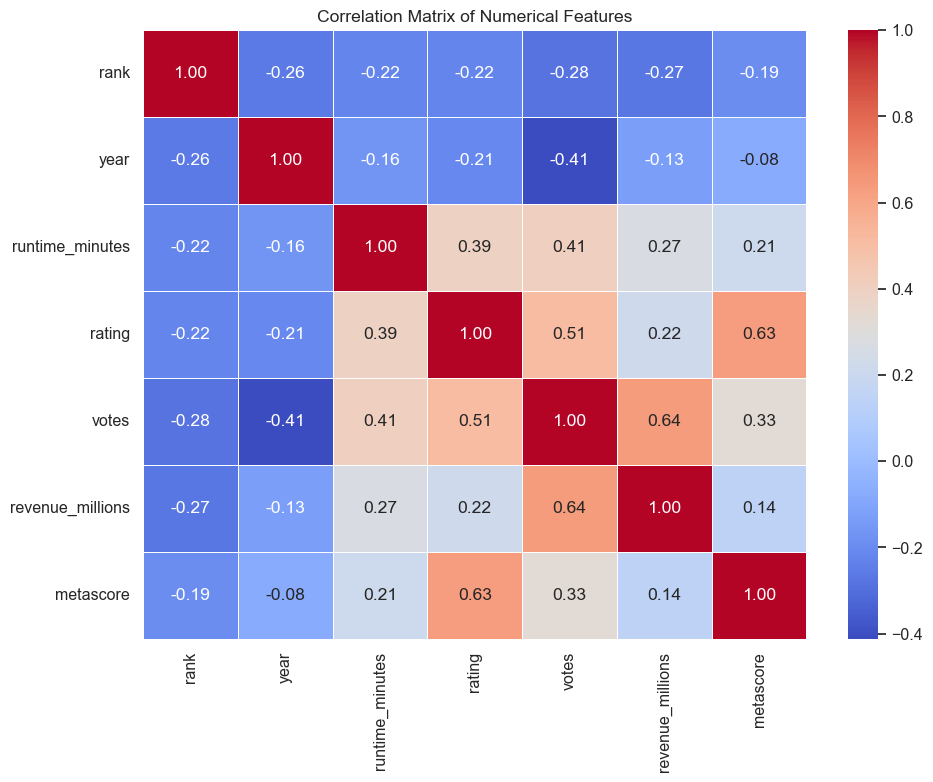

In [23]:
#show the correlationss 
pd.set_option('display.max_columns', None)
# (df.select_dtypes(include=np.number))
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap=PALETTE, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

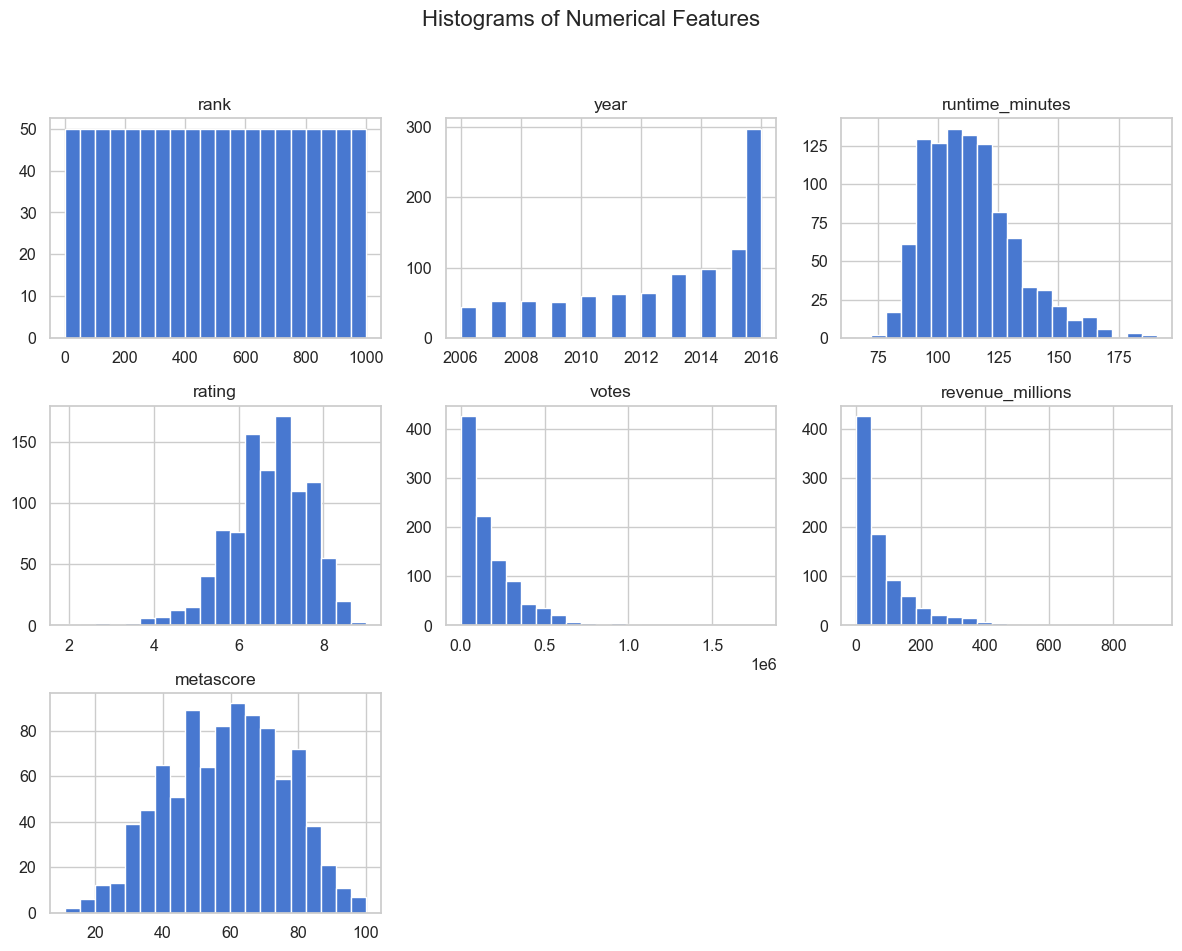

In [27]:
df.hist(figsize=(12, 10), bins=20)
plt.suptitle("Histograms of Numerical Features", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [30]:
df.columns

Index(['rank', 'title', 'genre', 'description', 'director', 'actors', 'year',
       'runtime_minutes', 'rating', 'votes', 'revenue_millions', 'metascore',
       'primary_genre'],
      dtype='object')

In [28]:


# ── 2. Basic cleaning ─────────────────────────────────────────────────────────
df["primary_genre"] = df["genre"].str.split(",").str[0].str.strip()
df["revenue_millions"] = pd.to_numeric(df["revenue_millions"], errors="coerce")
df["metascore"]        = pd.to_numeric(df["metascore"],        errors="coerce")

# ── 3. Descriptive statistics ─────────────────────────────────────────────────
print("── Descriptive Statistics ─────────────────────────────────")
print(df[["rating", "runtime_minutes", "revenue_millions", "votes", "metascore"]]
      .describe().round(2).to_string(), "\n")

── Descriptive Statistics ─────────────────────────────────
        rating  runtime_minutes  revenue_millions       votes  metascore
count  1000.00          1000.00            872.00     1000.00     936.00
mean      6.72           113.17             82.96   169808.26      58.99
std       0.95            18.81            103.25   188762.65      17.19
min       1.90            66.00              0.00       61.00      11.00
25%       6.20           100.00             13.27    36309.00      47.00
50%       6.80           111.00             47.98   110799.00      59.50
75%       7.40           123.00            113.72   239909.75      72.00
max       9.00           191.00            936.63  1791916.00     100.00 



In [29]:
# ── 4. GroupBy — avg rating & revenue by primary genre ───────────────────────
genre_stats = (
    df.groupby("primary_genre")
      .agg(
          avg_rating      = ("rating",           "mean"),
          avg_revenue_m   = ("revenue_millions", "mean"),
          total_votes     = ("votes",            "sum"),
          movie_count     = ("title",            "count"),
      )
      .round(2)
      .sort_values("avg_rating", ascending=False)
      .reset_index()
)
print("── GroupBy: Genre Stats ───────────────────────────────────")
print(genre_stats.to_string(index=False), "\n")

── GroupBy: Genre Stats ───────────────────────────────────
primary_genre  avg_rating  avg_revenue_m  total_votes  movie_count
    Animation        7.32         191.22     10199812           49
    Biography        7.32          55.95      9795886           64
        Drama        6.95          35.87     25241800          195
    Adventure        6.91         113.45     16925199           75
      Mystery        6.88          64.38      2842736           13
        Crime        6.81          41.04     10658872           71
      Romance        6.60          62.45       209144            2
       Action        6.59         122.09     69132934          293
       Comedy        6.49          51.58     20237033          175
     Thriller        5.96           0.32       311568           10
       Horror        5.87          39.95      3654029           46
      Fantasy        5.85          63.11       426892            4
       Sci-Fi        4.97          42.64       172350            3 



In [33]:
# ── 5. Pivot table — avg rating by year × primary genre ──────────────────────
pivot_rating = pd.pivot_table(
    df,
    values   = "revenue_millions",
    index    = "year",
    columns  = "primary_genre",
    aggfunc  = "count",
).round(2)

print("── Pivot Table: Avg Rating (Year × Genre) ─────────────────")
print(pivot_rating.to_string(), "\n")


── Pivot Table: Avg Rating (Year × Genre) ─────────────────
primary_genre  Action  Adventure  Animation  Biography  Comedy  Crime  Drama  Fantasy  Horror  Mystery  Romance  Sci-Fi  Thriller
year                                                                                                                             
2006             10.0        5.0        2.0        2.0     7.0    5.0    9.0      NaN     1.0      1.0      NaN     NaN       NaN
2007             10.0        6.0        3.0        3.0     5.0    8.0   11.0      1.0     2.0      NaN      NaN     NaN       0.0
2008             23.0        1.0        2.0        3.0     8.0    1.0   10.0      NaN     2.0      NaN      NaN     1.0       NaN
2009             14.0        5.0        4.0        3.0     9.0    1.0    8.0      0.0     3.0      NaN      NaN     NaN       NaN
2010             22.0        6.0        5.0        2.0     9.0    4.0    6.0      NaN     1.0      2.0      NaN     NaN       NaN
2011             20.0        5

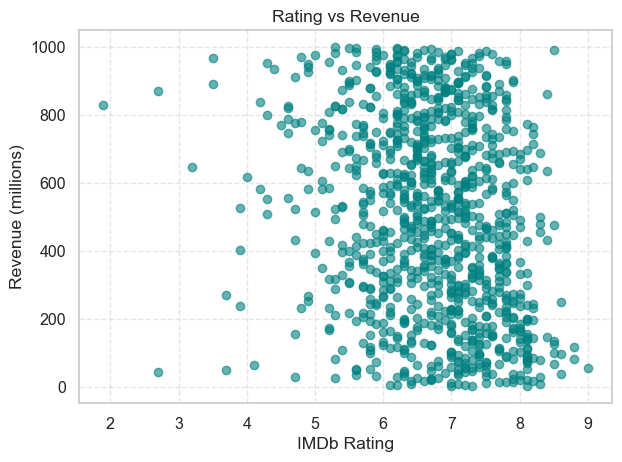

In [36]:
plt.scatter(df["rating"], df["rank"], alpha=0.6, color="teal")
plt.title("Rating vs Revenue")
plt.xlabel("IMDb Rating")
plt.ylabel("Revenue (millions)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [37]:
# ── 6. Crosstab — movie count by year × primary genre ────────────────────────
ct = pd.crosstab(df["year"], df["primary_genre"], margins=True)
print("── Crosstab: Movie Count (Year × Genre) ───────────────────")
print(ct.to_string(), "\n")

── Crosstab: Movie Count (Year × Genre) ───────────────────
primary_genre  Action  Adventure  Animation  Biography  Comedy  Crime  Drama  Fantasy  Horror  Mystery  Romance  Sci-Fi  Thriller   All
year                                                                                                                                   
2006               11          5          2          2       7      5     10        0       1        1        0       0         0    44
2007               11          6          3          3       6      9     11        1       2        0        0       0         1    53
2008               23          1          2          3       8      1     10        0       3        0        0       1         0    52
2009               14          5          4          3      10      1     10        1       3        0        0       0         0    51
2010               23          6          5          2       9      4      7        0       2        2        0       0     

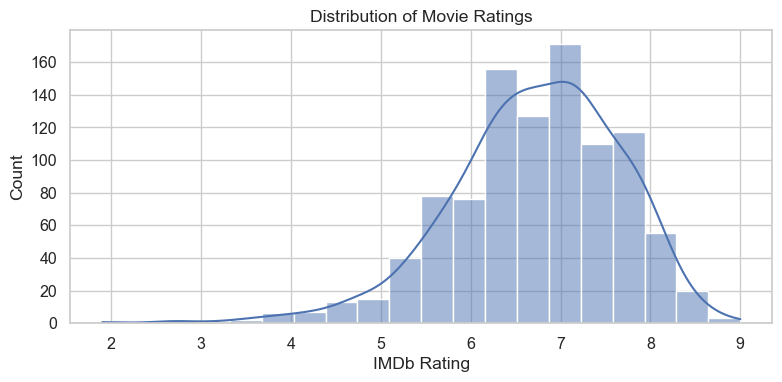

In [38]:


# ══════════════════════════════════════════════════════════════════════════════
#  VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

# ── Fig 1: Rating distribution ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["rating"], bins=20, kde=True, color="#4C72B0", ax=ax)
ax.set(title="Distribution of Movie Ratings", xlabel="IMDb Rating", ylabel="Count")
plt.tight_layout()
plt.show()
# plt.savefig(f"{FIG_DIR}/fig1_rating_distribution.png", dpi=150)
plt.close()

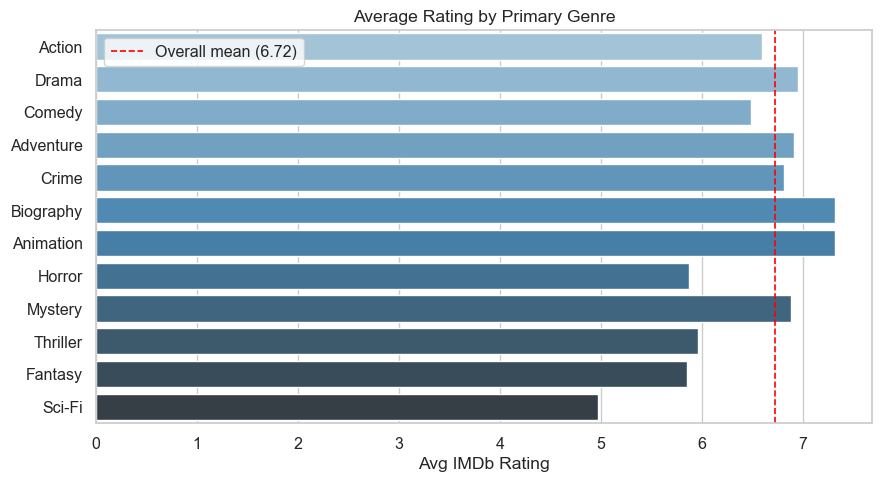

In [39]:
# ── Fig 2: Avg rating by genre (horizontal bar) ──────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
top_genres = genre_stats.nlargest(12, "movie_count")
sns.barplot(data=top_genres, y="primary_genre", x="avg_rating",
            palette="Blues_d", ax=ax)
ax.set(title="Average Rating by Primary Genre", xlabel="Avg IMDb Rating", ylabel="")
ax.axvline(df["rating"].mean(), color="red", linestyle="--", linewidth=1.2,
           label=f"Overall mean ({df['rating'].mean():.2f})")
ax.legend()
plt.tight_layout()
plt.show()
# plt.savefig(f"{FIG_DIR}/fig2_avg_rating_by_genre.png", dpi=150)
plt.close()

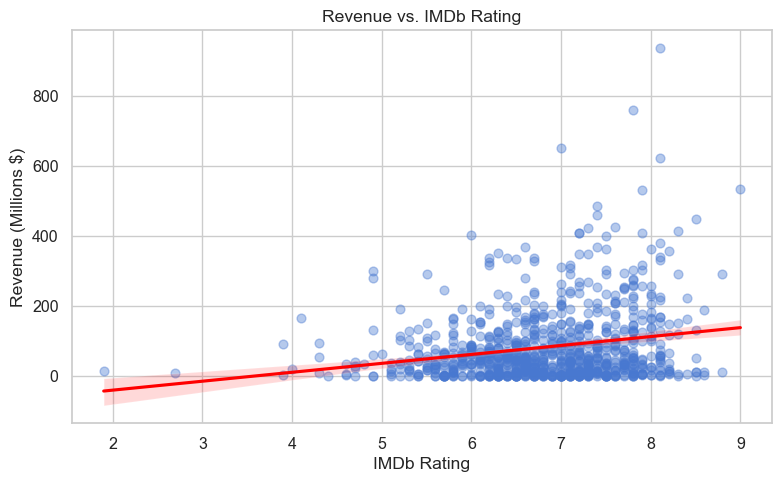

In [43]:
# ── Fig 3: Revenue vs Rating (scatter + regression) ──────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=df, x="rating", y="revenue_millions", 
            scatter_kws={"alpha": 0.4, "s": 40}, line_kws={"color": "red"},
            ax=ax)
ax.set(title="Revenue vs. IMDb Rating", xlabel="IMDb Rating",
       ylabel="Revenue (Millions $)")
plt.tight_layout()
plt.show()
# plt.savefig(f"{FIG_DIR}/fig3_revenue_vs_rating.png", dpi=150)
plt.close()


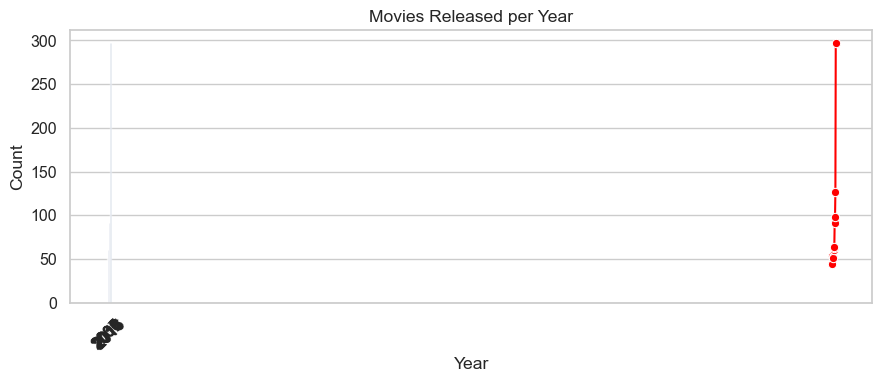

In [46]:
# ── Fig 4: Movies released per year (line + bar) ─────────────────────────────
yearly = df.groupby("year").size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=yearly, x="year", y="count", color="#4C72B0", alpha=0.6, ax=ax)
sns.lineplot(data=yearly, x="year", y="count", color="red", marker="o", ax=ax)
ax.set(title="Movies Released per Year", xlabel="Year", ylabel="Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
# plt.savefig(f"{FIG_DIR}/fig4_movies_per_year.png", dpi=150)
plt.close()


In [45]:
yearly 

,year,count
0,2006,44
1,2007,53
2,2008,52
3,2009,51
4,2010,60
5,2011,63
6,2012,64
7,2013,91
8,2014,98
9,2015,127


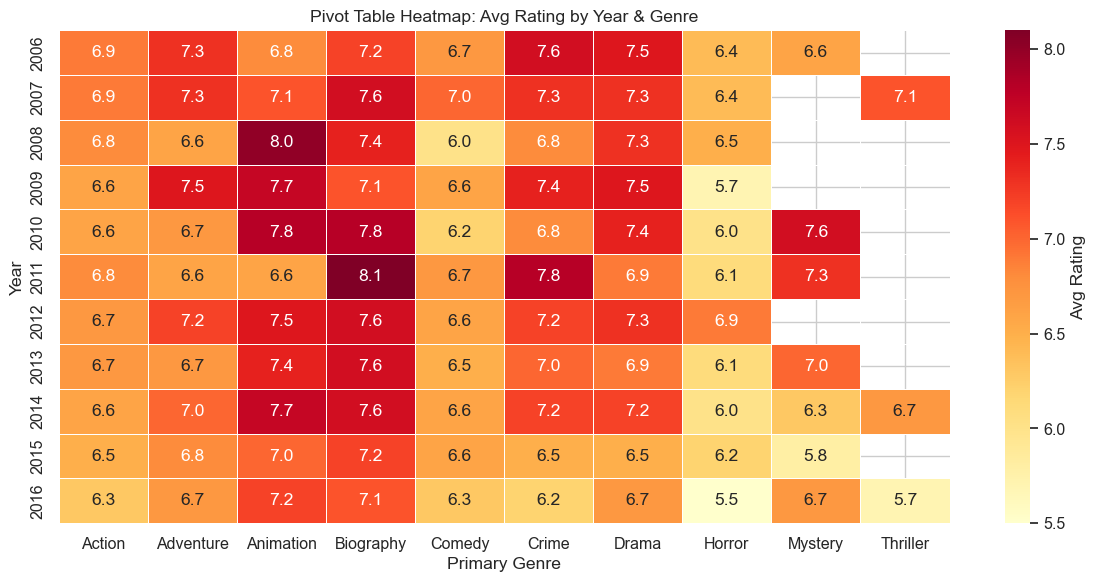

In [48]:
# ── Fig 5: Heatmap — pivot table (year × genre avg rating) ───────────────────
# Keep only genres with enough data
common_genres = (df["primary_genre"].value_counts()
                                    .loc[lambda x: x >= 5].index.tolist())
pivot_hm = pd.pivot_table(
    df[df["primary_genre"].isin(common_genres)],
    values="rating", index="year", columns="primary_genre", aggfunc="mean"
).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_hm, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.4, ax=ax, cbar_kws={"label": "Avg Rating"})
ax.set(title="Pivot Table Heatmap: Avg Rating by Year & Genre",
       xlabel="Primary Genre", ylabel="Year")
plt.tight_layout()
plt.show()
# plt.savefig(f"{FIG_DIR}/fig5_heatmap_rating_year_genre.png", dpi=150)
plt.close()


── Descriptive Statistics ─────────────────────────────────
        rating  runtime_minutes  revenue_millions       votes  metascore
count  1000.00          1000.00            872.00     1000.00     936.00
mean      6.72           113.17             82.96   169808.26      58.99
std       0.95            18.81            103.25   188762.65      17.19
min       1.90            66.00              0.00       61.00      11.00
25%       6.20           100.00             13.27    36309.00      47.00
50%       6.80           111.00             47.98   110799.00      59.50
75%       7.40           123.00            113.72   239909.75      72.00
max       9.00           191.00            936.63  1791916.00     100.00 

── GroupBy: Genre Stats ───────────────────────────────────
primary_genre  avg_rating  avg_revenue_m  total_votes  movie_count
    Animation        7.32         191.22     10199812           49
    Biography        7.32          55.95      9795886           64
        Drama       

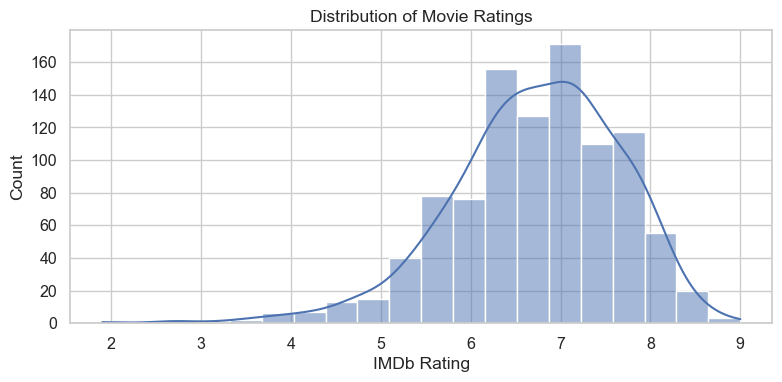

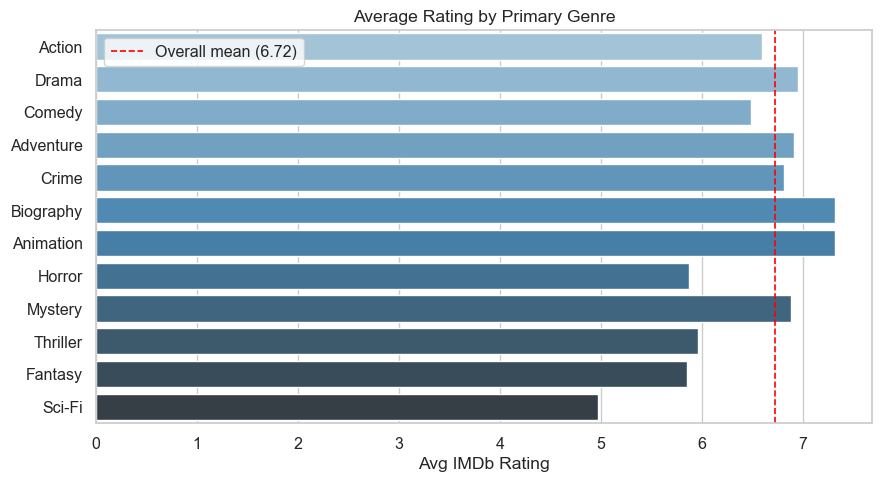

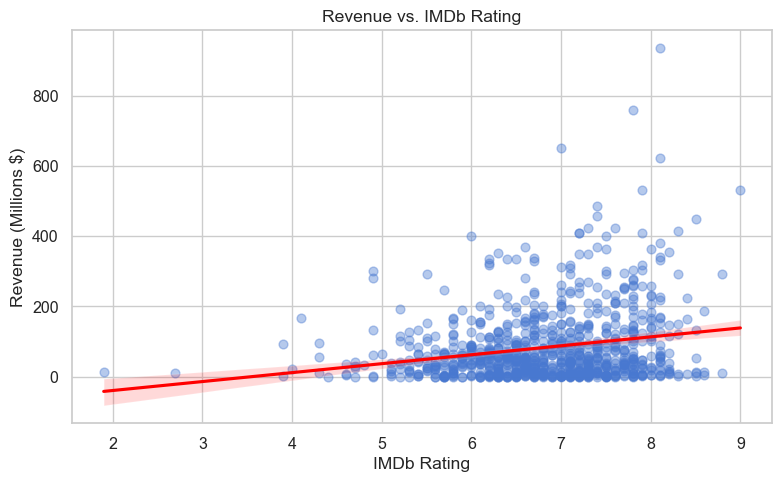

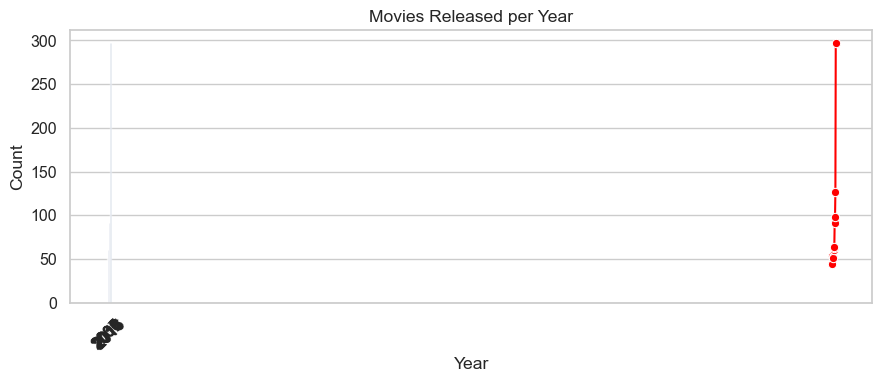

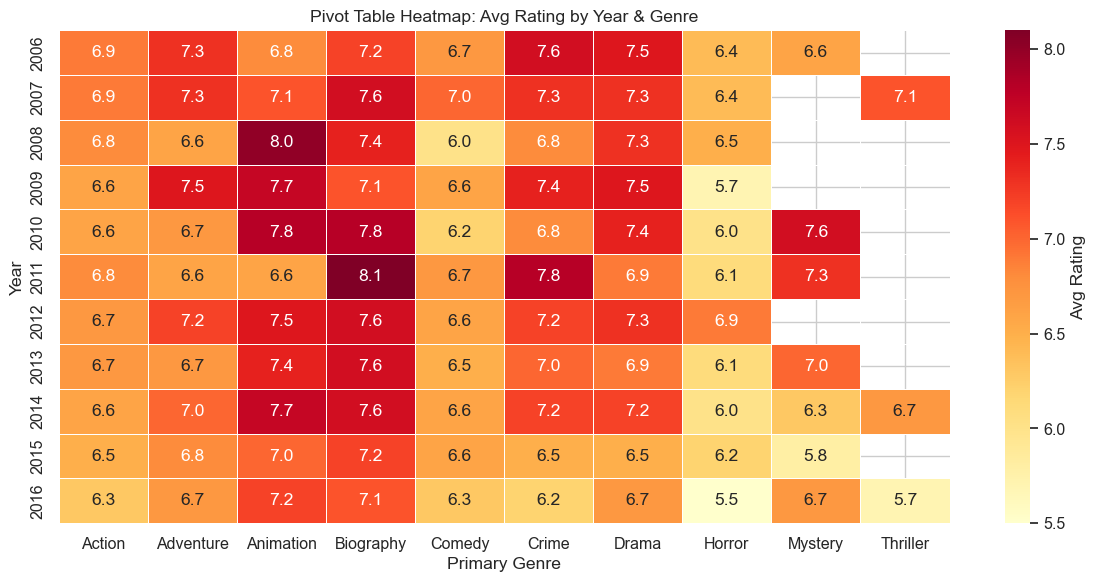

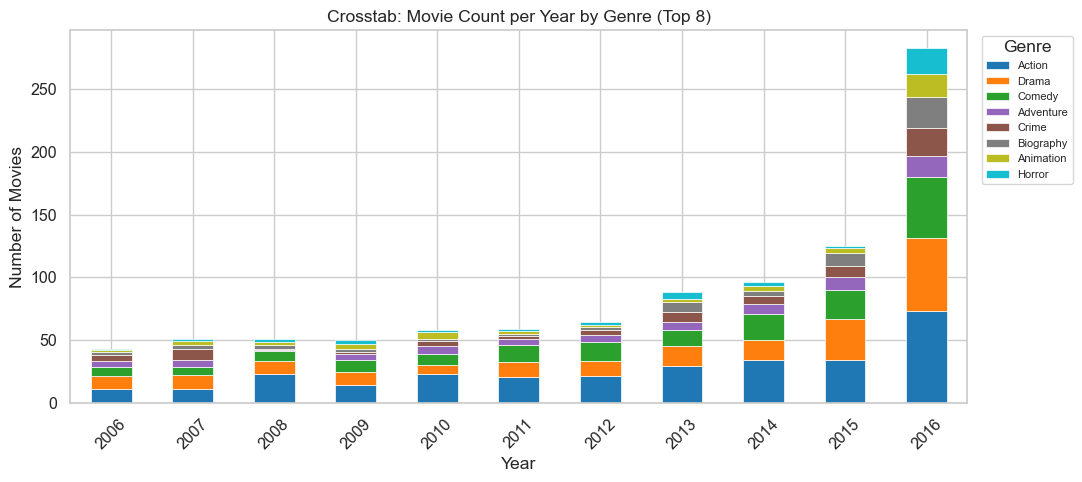

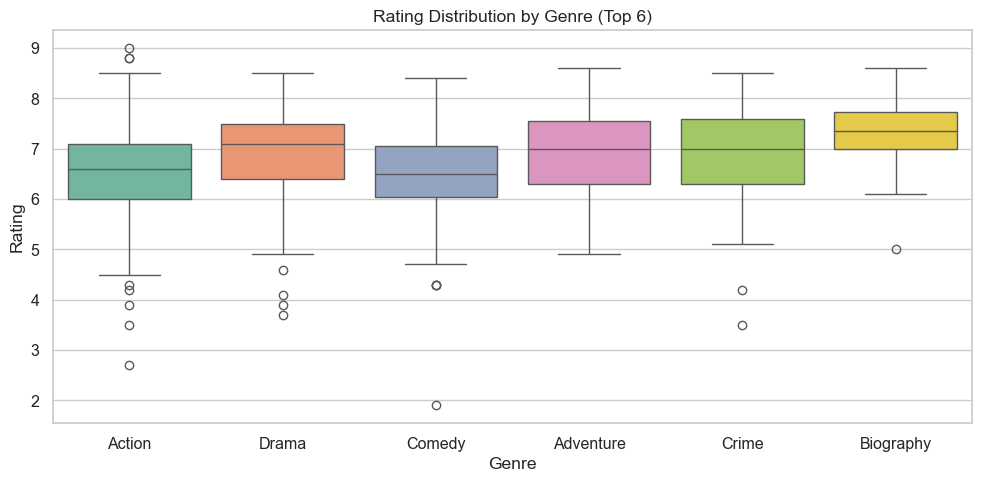

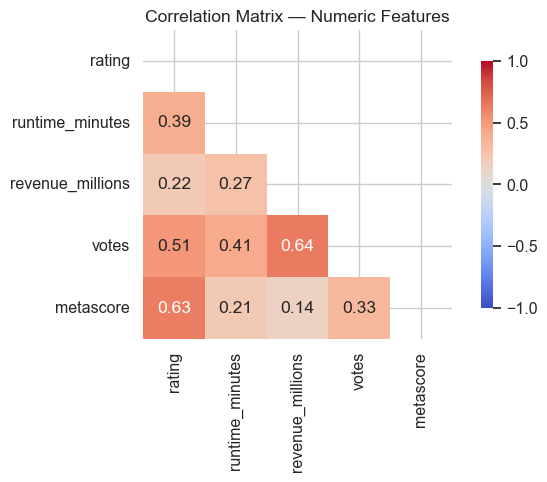

── All figures saved ──────────────────────────────────────
fig1_rating_distribution.png
fig2_avg_rating_by_genre.png
fig3_revenue_vs_rating.png
fig4_movies_per_year.png
fig5_heatmap_rating_year_genre.png
fig6_crosstab_year_genre.png
fig7_boxplot_rating_genre.png
fig8_correlation_heatmap.png


In [ ]:


# ── Fig 6: Crosstab stacked bar — movie count year × genre ───────────────────
ct_plot = ct.drop("All", axis=0).drop("All", axis=1)
ct_plot = ct_plot[ct_plot.sum().nlargest(8).index]       # top-8 genres
ct_plot.plot(kind="bar", stacked=True, figsize=(11, 5),
             colormap="tab10", edgecolor="white", linewidth=0.5)
plt.title("Crosstab: Movie Count per Year by Genre (Top 8)")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.legend(title="Genre", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig(f"{FIG_DIR}/fig6_crosstab_year_genre.png", dpi=150)
plt.show()
plt.close()

# ── Fig 7: Box plot — rating by top-6 genres ─────────────────────────────────
top6 = (df["primary_genre"].value_counts().head(6).index.tolist())
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df[df["primary_genre"].isin(top6)],
            x="primary_genre", y="rating",
            palette="Set2", order=top6, ax=ax)
ax.set(title="Rating Distribution by Genre (Top 6)", xlabel="Genre", ylabel="Rating")
plt.tight_layout()
plt.show()
# plt.savefig(f"{FIG_DIR}/fig7_boxplot_rating_genre.png", dpi=150)
plt.close()

# ── Fig 8: Correlation heatmap ────────────────────────────────────────────────
num_cols = ["rating", "runtime_minutes", "revenue_millions", "votes", "metascore"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, ax=ax, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()
# plt.savefig(f"{FIG_DIR}/fig8_correlation_heatmap.png", dpi=150)
plt.close()

print("── All figures saved ──────────────────────────────────────")
print("fig1_rating_distribution.png")
print("fig2_avg_rating_by_genre.png")
print("fig3_revenue_vs_rating.png")
print("fig4_movies_per_year.png")
print("fig5_heatmap_rating_year_genre.png")
print("fig6_crosstab_year_genre.png")
print("fig7_boxplot_rating_genre.png")
print("fig8_correlation_heatmap.png")

In [3]:
pwd

'/Users/armandovieira/medgical/code'